## Fitbit : Calorie Burn Prediction & Workout Pattern Clustering Using Fitbit Data

## Import Required packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



## Read & understand the dataset

In [43]:


# Data load
df = pd.read_csv('Fitbit_dataset.csv')
df.head()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [44]:
# Basic info
df.shape        
df.info()       
df.describe()   
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  str    
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  str    
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null  int64  
 1

Unnamed: 0                       0
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
dtype: int64

## Data Preprocessing

**Data type ensuring**

In [45]:
df['Workout_Type'].dtype
df['Workout_Type']=df['Workout_Type'].astype(str)
df['Gender']=df['Gender'].astype(str)
df['Gender']=df['Gender'].str.lower()
df['Workout_Type']=df['Workout_Type'].str.lower()

In [46]:
df = df.drop(columns=['Unnamed: 0'])

**Missing values handling**

In [47]:
df.fillna(df.median(numeric_only=True), inplace=True)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,56,female,53.8,1.62,163.0,149.0,71.0,1.01,hiit,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,46,male,54.9,1.75,170.0,126.0,73.0,0.25,yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,32,female,68.5,1.61,190.0,171.0,60.0,0.33,hiit,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,25,male,98.8,1.86,189.0,135.0,69.0,0.78,yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,38,male,95.5,1.71,176.0,138.0,66.0,0.55,cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14097,18,male,75.7,1.76,205.0,143.0,67.0,0.62,yoga,23.3,3.7,4,1,24.3,3.0,0.550725,1.652174,77.5
14098,54,male,66.4,1.71,162.0,131.0,73.0,0.93,cardio,15.0,2.7,3,1,22.7,7.0,0.651685,4.561798,281.7
14099,23,female,74.7,1.52,204.0,161.0,61.0,0.99,strength,19.3,4.3,3,1,32.5,6.0,0.699301,4.195804,310.3
14100,43,male,70.8,1.69,171.0,154.0,55.0,1.01,hiit,12.3,3.9,7,3,24.9,9.5,0.853448,8.107759,579.8


**Outlier dedection using IQR method**

In [48]:

for col in ['Max_BPM', 'Avg_BPM', 'Calories_Burned (kcal)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

## EDA

**Distribution of Calories Burned**

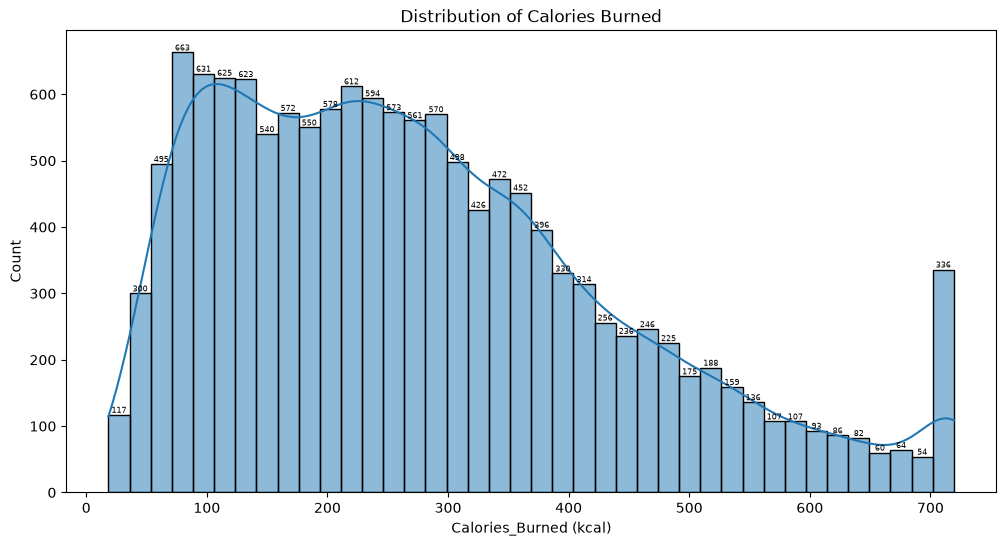

In [49]:


plt.figure(figsize=(12,6))

ax = sns.histplot(
    data=df,
    x='Calories_Burned (kcal)',
    bins=40,
    kde=True
)

plt.title("Distribution of Calories Burned")

for patch in ax.patches:
    height = patch.get_height()
    if height > 0: 
        ax.text(
            patch.get_x() + patch.get_width()/2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=6,
            rotation=0
        )

plt.show()

**Key Insights**

**Most users burn between 100–350 kcal**, indicating that moderate workouts are the most common.

The distribution is right-skewed, meaning only **a few users burn very high calories.**

The number of users decreases as calories burned increases, showing that high-intensity workouts are less frequent.

A spike is observed near 719 kcal because many records have the same calorie burn value (719.45 kcal).
**This indicates repeated workout patterns or similar exercise conditions in the dataset.**

**Correlation heatmap**

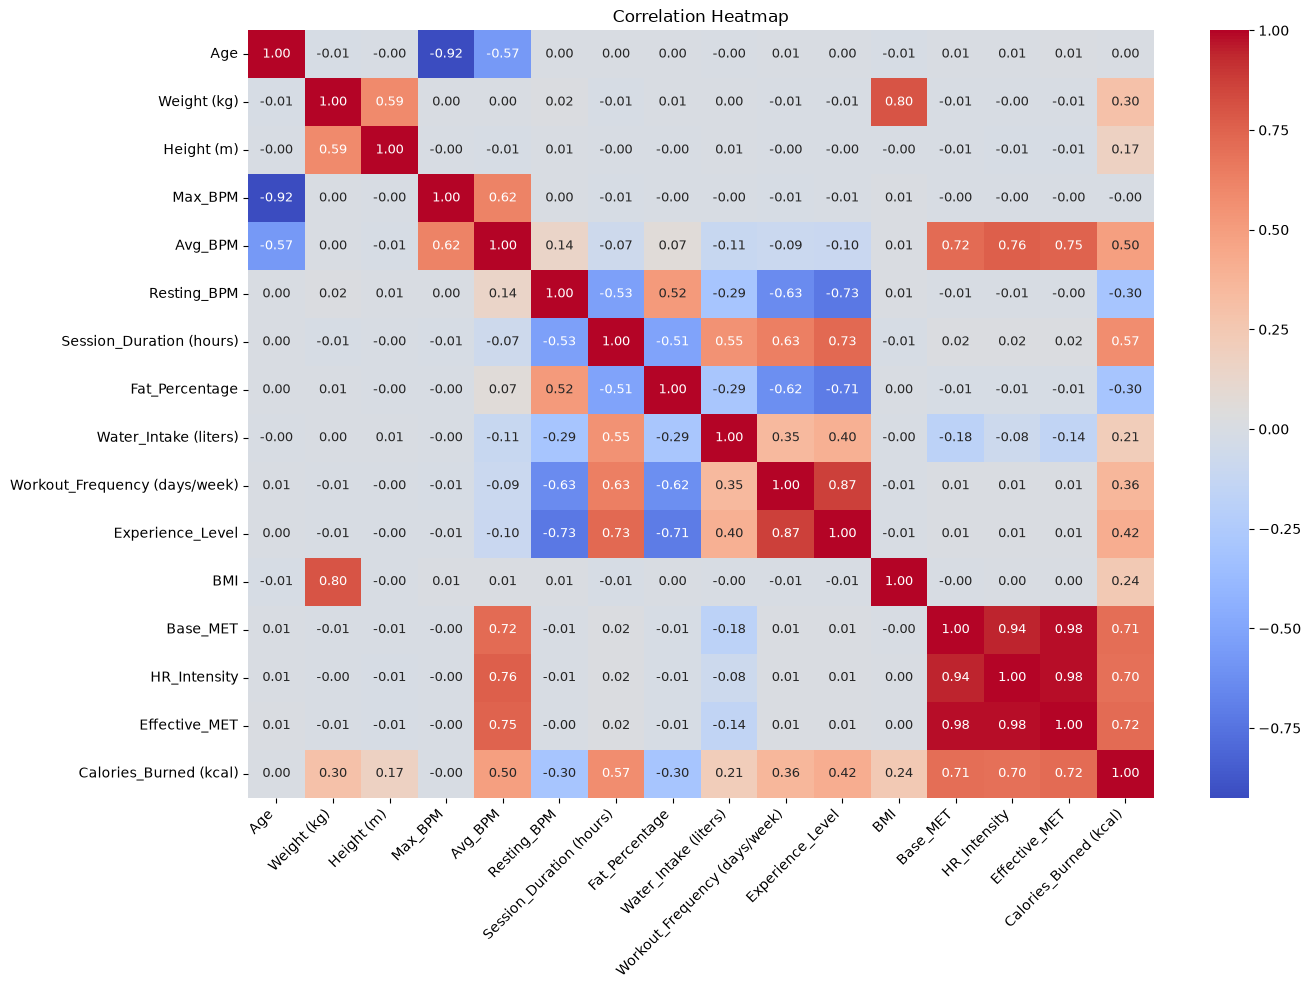

In [50]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size":9}
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title("Correlation Heatmap")
plt.tight_layout()

plt.show()

**Key Insights**

**Calories_Burned has a strong positive correlation with Effective_MET (≈0.72)**, indicating that higher workout intensity leads to more calories burned.

**HR_Intensity and Base_MET are highly correlated with Effective_MET (≈0.98–0.99)**, showing that these features measure similar aspects of workout intensity.

**Session Duration has a moderate positive correlation with Calories_Burned (≈0.57)**, meaning longer workouts generally burn more calories.

**Age and Gender show very weak correlation with Calories_Burned**, suggesting they have less direct impact compared to workout-related features.
One-line Conclusion

**Workout intensity (Effective_MET, HR_Intensity, Base_MET) and Session Duration are the most influential factors affecting Calories Burned**

**Workout type vs Calories**

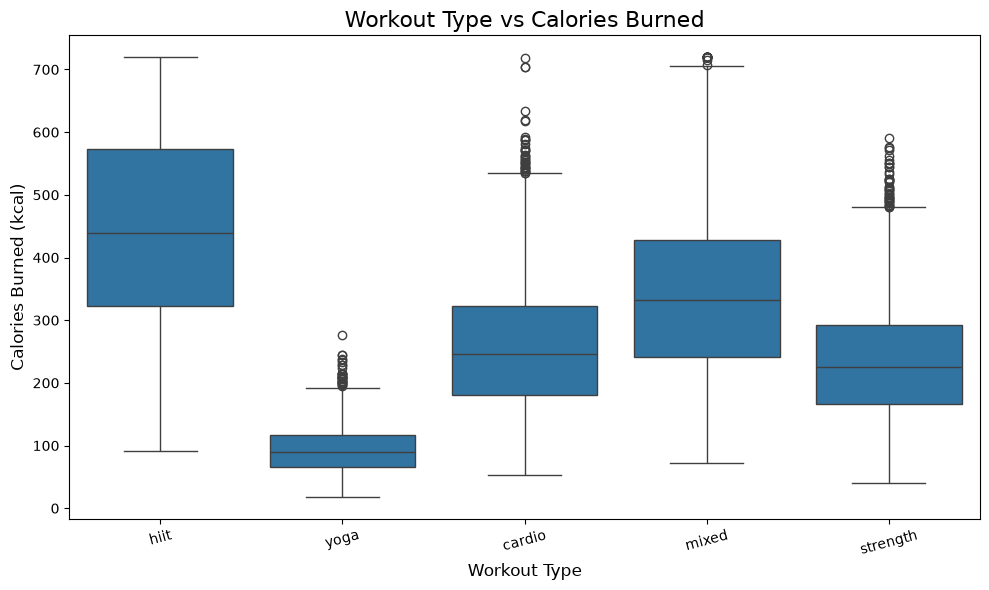

In [51]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Workout_Type',
    y='Calories_Burned (kcal)',
    data=df
)

plt.title('Workout Type vs Calories Burned', fontsize=16)
plt.xlabel('Workout Type', fontsize=12)
plt.ylabel('Calories Burned (kcal)', fontsize=12)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Key Insights**

**HIIT has the highest median calorie burn**, indicating it is the most effective workout for burning calories.

**Yoga has the lowest calorie burn**, making it a lower-intensity workout compared to the others.

**Mixed workouts show high variability**, meaning users burn a wide range of calories depending on workout intensity and duration.

**Outliers are present in all workout types**, indicating some users burn significantly more calories than the typical workout session.

## Model building


**Categorical Encoding**

In [52]:

from operator import le

encode = LabelEncoder()
df['Gender'] = encode.fit_transform(df['Gender'])          # Male=1, Female=0
df['Workout_Type'] = encode.fit_transform(df['Workout_Type'])
df['Experience_Level'] = encode.fit_transform(df['Experience_Level'])

**Feature & Target spliting**


In [53]:
X = df.drop('Calories_Burned (kcal)', axis=1)  # Features
y = df['Calories_Burned (kcal)']               # Target


**Train/Test spliting**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Scaling**
`StandardScaler`

In [55]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:

#we should try multiple models to find the best one for our regression task. Here are some common regression models we can use:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(),
    'Lasso':             Lasso(),
    'KNN':               KNeighborsRegressor(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(random_state=42),
    'SVR':               SVR(),
    'XGBoost':           XGBRegressor(random_state=42)
}

# we should loop through all models to train and evaluate them
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

# Results table
results_df = pd.DataFrame(results).T

print(results_df.sort_values('R2', ascending=False))

Linear Regression: MAE=31.80, RMSE=45.76, R²=0.9261
Ridge: MAE=31.80, RMSE=45.76, R²=0.9261
Lasso: MAE=32.11, RMSE=46.51, R²=0.9237
KNN: MAE=28.28, RMSE=39.29, R²=0.9455
Decision Tree: MAE=7.56, RMSE=11.74, R²=0.9951
Random Forest: MAE=3.65, RMSE=7.03, R²=0.9983
SVR: MAE=28.32, RMSE=49.46, R²=0.9137
XGBoost: MAE=5.30, RMSE=7.95, R²=0.9978
                         MAE       RMSE        R2
Random Forest       3.646792   7.027644  0.998258
XGBoost             5.298238   7.950376  0.997770
Decision Tree       7.556097  11.740671  0.995137
KNN                28.281560  39.287161  0.945547
Linear Regression  31.795463  45.759902  0.926127
Ridge              31.798691  45.760223  0.926126
Lasso              32.110532  46.513447  0.923674
SVR                28.321170  49.455894  0.913711


**Best Model deployement**

In [57]:
# Best model = Random Forest or XGBoost (usually)
best_model = RandomForestRegressor(random_state=5)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

## Visualization of Best Model

**Actual vs Predicted plot & Feature importance**

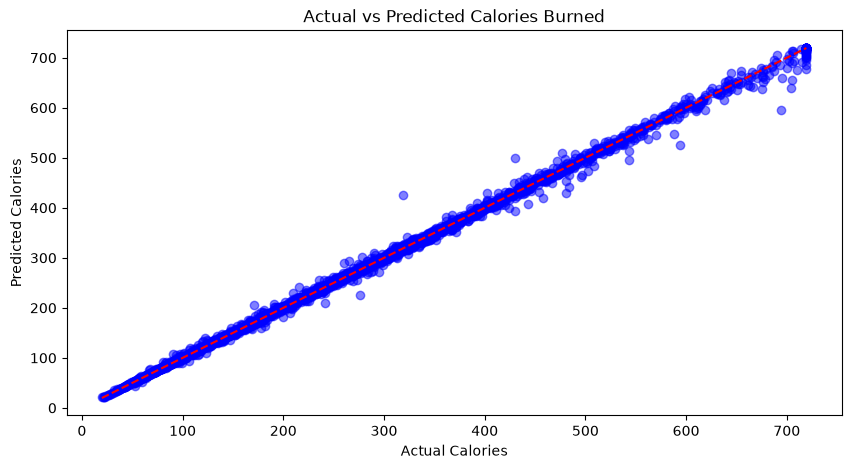

In [59]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted Calories Burned')
plt.show()



**Key Insights**

**Most data points lie close to the red reference line**, indicating that the model predicts calorie burn accurately.

**There is a strong agreement between actual and predicted calorie values**, showing good model performance.

**Only a few points deviate from the reference line**, indicating a small number of prediction errors (outliers).

**The model performs consistently across both low and high calorie values**, demonstrating good generalization.

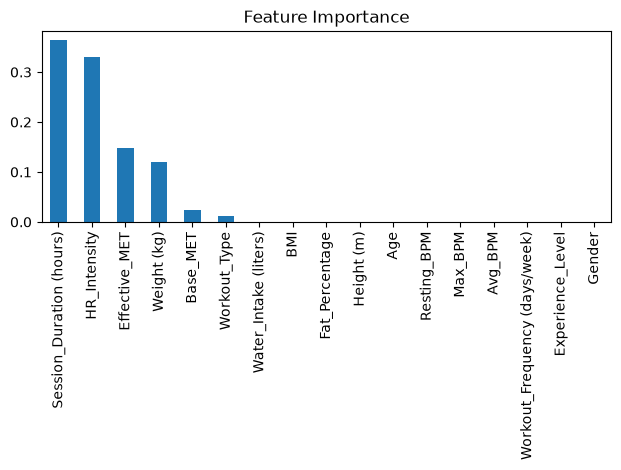

In [ ]:
# Feature Importance

feat_imp = pd.Series(best_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importance')

plt.tight_layout()
plt.show()

**Key Insights**

**Session Duration is the most important feature for predicting calories burned.**

**HR Intensity and Effective MET are also major contributors**, showing that workout intensity strongly affects calorie burn.

**Weight has a moderate impact**, indicating that body weight influences the number of calories burned.

Features like **Age, Gender, Height, and Workout Frequency have very low importance**, meaning they contribute less to the prediction.

## Unsupervised learning Model

**Scaling**

In [ ]:
# only dropout Workout_Type (should do label  cluster )

df_cluster = df.drop(['Workout_Type', 'Calories_Burned (kcal)'], axis=1)

# Scale 
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(df_cluster)


**PCA Dimensionality Reduction**

PC1 Explained Variance : 24.65%
PC2 Explained Variance : 22.57%
Total Explained Variance : 47.21%


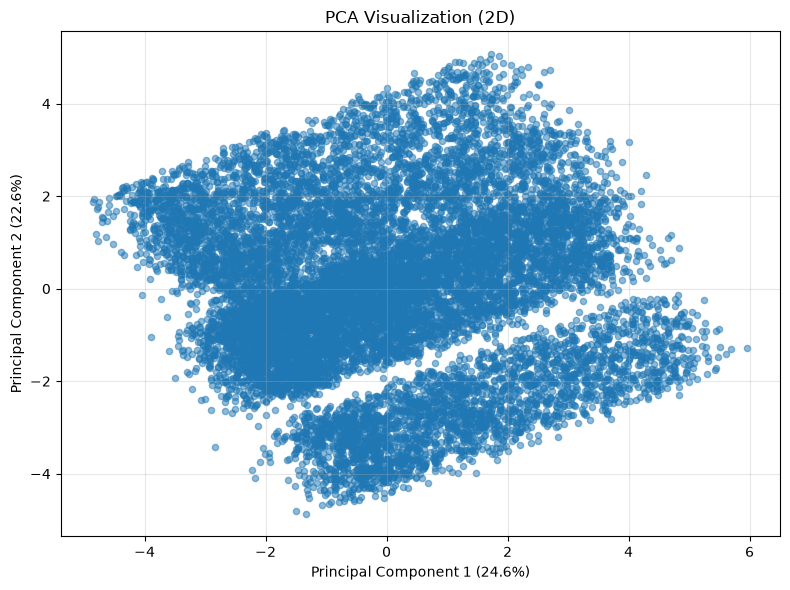

In [69]:

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_

print(f"PC1 Explained Variance : {explained_var[0]:.2%}")
print(f"PC2 Explained Variance : {explained_var[1]:.2%}")
print(f"Total Explained Variance : {explained_var.sum():.2%}")

# PCA Scatter Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.5,
    s=20
)

plt.xlabel(f'Principal Component 1 ({explained_var[0]:.1%})')
plt.ylabel(f'Principal Component 2 ({explained_var[1]:.1%})')
plt.title('PCA Visualization (2D)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

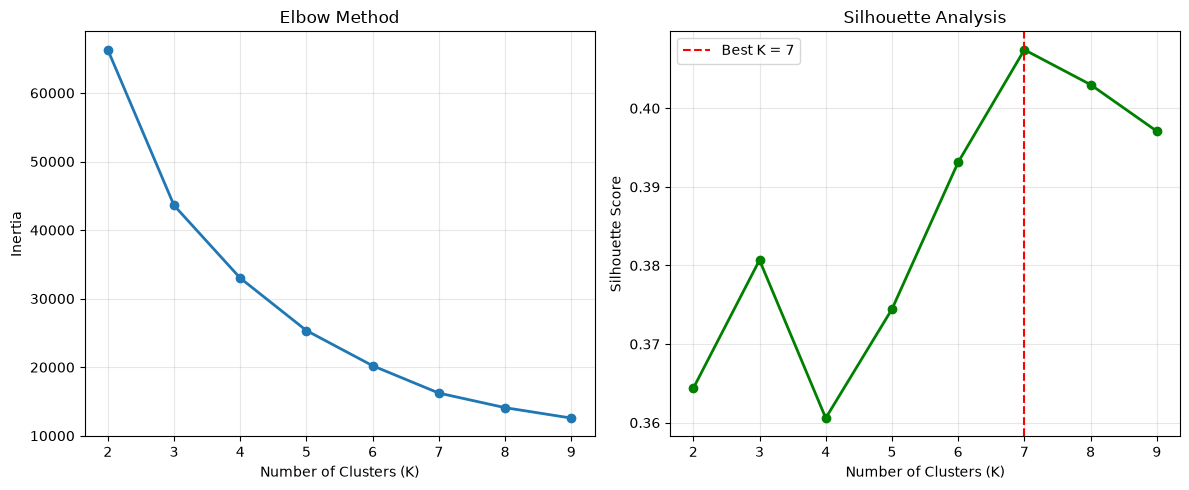

Optimal Number of Clusters (K): 7
Best Silhouette Score: 0.407


In [ ]:
# Find the optimal number of clusters
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Best K based on Silhouette Score
best_k = K_range[sil_scores.index(max(sil_scores))]

# Plot
plt.figure(figsize=(12,5))

# Elbow Method
plt.subplot(1,2,1)
plt.plot(K_range, inertias, marker='o', linewidth=2)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(alpha=0.3)

# Silhouette Score
plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o', linewidth=2, color='green')
plt.axvline(best_k, color='red', linestyle='--',
            label=f'Best K = {best_k}')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Optimal Number of Clusters (K): {best_k}")
print(f"Best Silhouette Score: {max(sil_scores):.3f}")

Silhouette Score: 0.3606


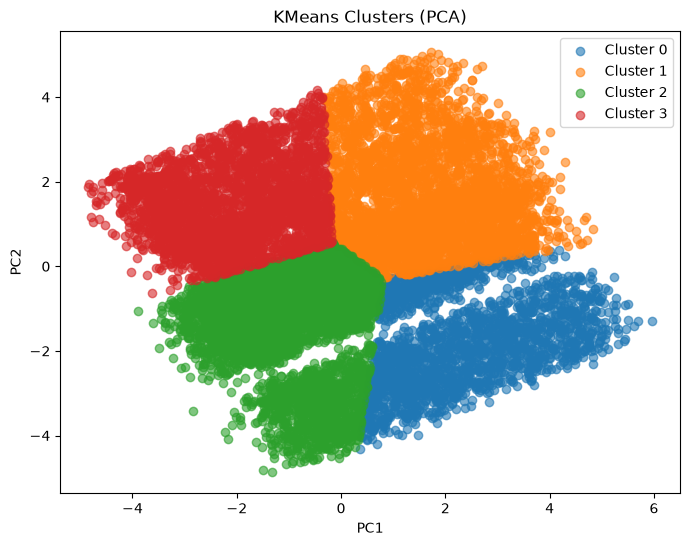

In [65]:
# Best K select  (elbow graph use - usually 3 or 4)
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Silhouette Score
score = silhouette_score(X_pca, df['Cluster'])
print(f"Silhouette Score: {score:.4f}")  # ≥ 0.15 comes

# Cluster Visualization
plt.figure(figsize=(8,6))
for i in range(best_k):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {i}', alpha=0.6)
plt.legend()
plt.title('KMeans Clusters (PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

Optimal Number of Clusters : 4
Silhouette Score : 0.361


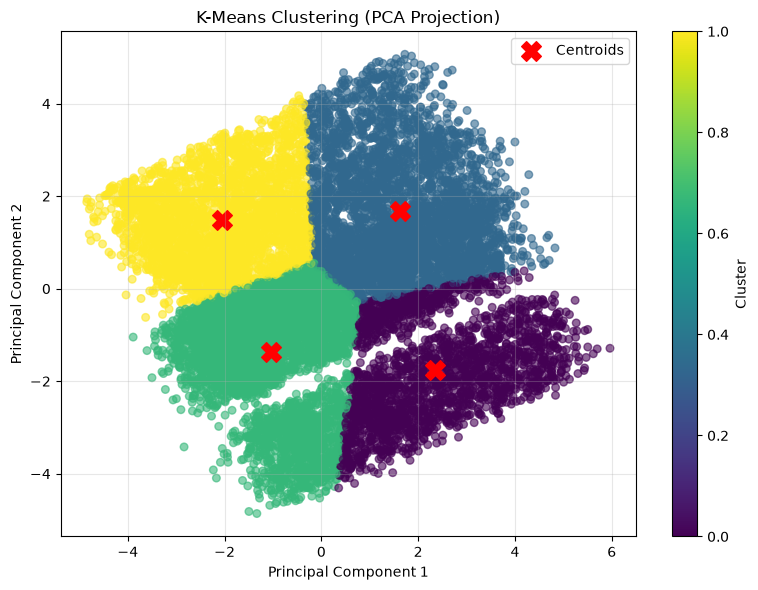

In [72]:

# Best K from Elbow & Silhouette Analysis
best_k = 4

# Train KMeans
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

# Cluster Assignment
df['Cluster'] = kmeans.fit_predict(X_pca)

# Silhouette Score
score = silhouette_score(X_pca, df['Cluster'])

print(f"Optimal Number of Clusters : {best_k}")
print(f"Silhouette Score : {score:.3f}")

# Cluster Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    cmap='viridis',
    s=30,
    alpha=0.6
)

# Plot Cluster Centers
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=200,
    color='red',
    label='Centroids'
)

plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Cluster Summary
         Avg_BPM  Session_Duration (hours)  Workout_Frequency (days/week)  \
Cluster                                                                     
0         129.36                      0.97                           5.09   
1         151.65                      1.09                           5.82   
2         143.73                      0.65                           3.01   
3         164.24                      0.69                           3.26   

         Experience_Level  
Cluster                    
0                    1.78  
1                    2.30  
2                    0.36  
3                    0.54  


<Figure size 800x500 with 0 Axes>

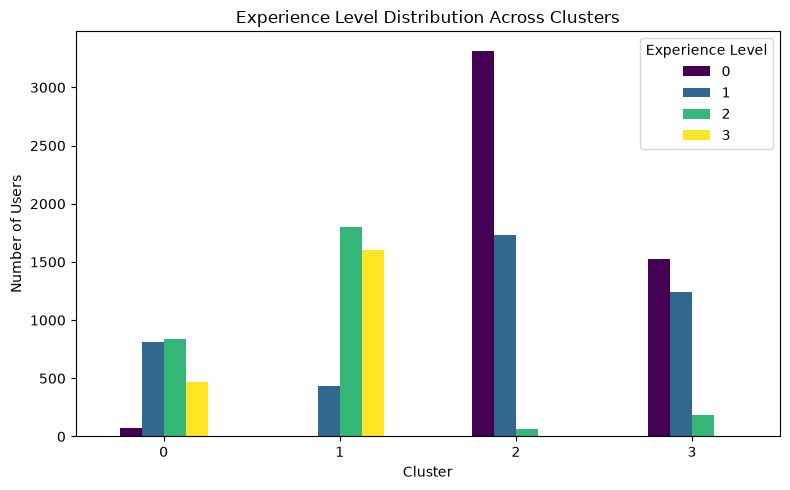

In [73]:
# Cluster Profile Summary
cluster_summary = df.groupby('Cluster').agg({
    'Avg_BPM': 'mean',
    'Session_Duration (hours)': 'mean',
    'Workout_Frequency (days/week)': 'mean',
    'Experience_Level': 'mean'
}).round(2)

print("Cluster Summary")
print(cluster_summary)

# Experience Level Distribution by Cluster
plt.figure(figsize=(8,5))

pd.crosstab(
    df['Cluster'],
    df['Experience_Level']
).plot(
    kind='bar',
    colormap='viridis',
    figsize=(8,5)
)

plt.title("Experience Level Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.legend(title="Experience Level")
plt.tight_layout()

plt.show()

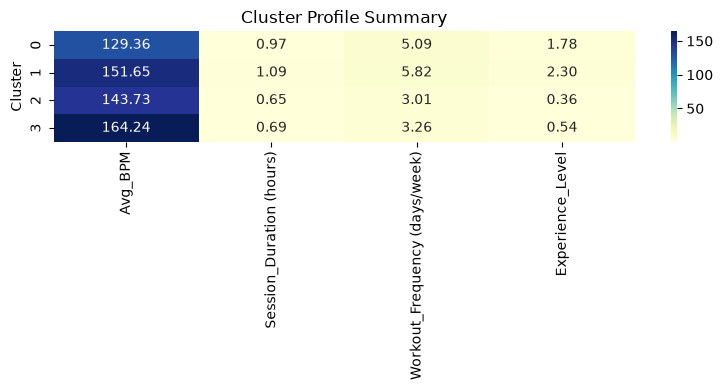

In [74]:
import seaborn as sns

plt.figure(figsize=(8,4))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Cluster Profile Summary")
plt.tight_layout()
plt.show()